# MWE: SPARCO imaging around a binary star, following Hillen et al. (2016)

The previous MWE reconstructed PIONIER data of IRAS 08544-4431 with a single star, a resolved background and an image. It left a knot of compact emission next to the star. Hillen et al. (2016, arXiv:1603.03023) explain it: the central star is a binary, and the companion is brighter and hotter than a main-sequence star should be, which they attribute to a circum-companion accretion disc. Their model has the following parts:
- a primary with a stellar spectrum;
- a secondary point source with a blackbody spectrum of free temperature, which carries the companion's circumstellar emission;
- a ring and a resolved background, also with blackbody spectra;
- the binary's centre of mass anchored to the centre of the ring, using a mass ratio from spectroscopy.

They then reconstruct the image with the binary subtracted, with an environment whose spectrum is a power law in wavelength.

This notebook does the same with drpangloss. It uses `drpangloss.spectra.BlackBody` for the temperatures, and a model function to anchor the ring to the binary. You should come away knowing how to build a SPARCO model with temperatures and constraints between components, and how its spectral parameters relate to the paper's.

In [1]:
import os
import sys
from pathlib import Path

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.insert(0, str(root / "src"))

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro.distributions as dist
from tqdm.auto import tqdm

from drpangloss.fitting import fit
from drpangloss.imaging import MaxEntropy, beam, image_priors, l_curve
from drpangloss.models import Image, ModulatedGaussianRim, PointSource, Resolved, System, circular_support
from drpangloss.oidata import OIData
from drpangloss.oifits import read_oifits
from drpangloss.plotting import plot_model, plot_residual_map
from drpangloss.spectra import BlackBody, PowerLaw

# The PIONIER files of ESO programme 094.D-0865, from the ESO archive.
DATA = Path(os.environ.get("IRAS08544_DATA", "data/IRAS08544"))
files = sorted(DATA.glob("PIONI.*_oidataCalibrated.fits"))
if not files:
    raise FileNotFoundError(f"No PIONIER files in {DATA}: set IRAS08544_DATA to their directory.")
data = OIData(read_oifits(files))
L0 = 1.65e-6
print(f"{len(files)} files: {data.vis.size} V², {data.phi.size} closure phases; beam {beam(data).major_mas:.1f} × {beam(data).minor_mas:.1f} mas")

27 files: 828 V², 504 closure phases; beam 3.2 × 2.5 mas


## The parametric model, anchored to the centre of mass

The primary is a point source with a 7250 K blackbody spectrum; the paper uses a Kurucz atmosphere at that temperature. The secondary, the ring and the background have blackbody spectra with free temperatures, all normalised at 1.65 µm. Every flux ratio is relative to the primary's, so a component's fraction of the total at 1.65 µm is its ratio over the sum of ratios: these are SPARCO's f_i. The ring is an inclined Gaussian ring with first- and second-order azimuthal modulations.

The paper anchors the binary's centre of mass to the centre of the ring. With the primary at the origin, the ring's centre is then at κ = q/(1+q) times the secondary's offset, where q is the mass ratio of secondary to primary. The paper's masses, about 0.6 M☉ for the primary and 1.5–2 M☉ for the secondary, give q ≈ 3, so κ = 0.75. A model function puts the ring there. Every fit below is checked for convergence.

In [2]:
template = System(
    primary=PointSource(flux=BlackBody(1.0, 7250.0)),
    secondary=PointSource(flux=BlackBody(0.08, 4000.0), dra=0.6, ddec=0.4),
    rim=ModulatedGaussianRim(14.2, 3.3, 20.0, 0.0, az_amps=(0.3, 0.1), az_pas=(45.0, 0.0), flux=BlackBody(0.35, 1200.0)),
    bg=Resolved(flux=BlackBody(0.27, 2400.0)),
)
kappa = 0.75


def anchored(**params):
    model = template.set(list(params), list(params.values()))
    offset = [kappa * params["secondary.dra"], kappa * params["secondary.ddec"]]
    return model.set(["rim.dra", "rim.ddec"], offset)


U = dist.Uniform
priors = {
    "secondary.flux.ratio": U(0.0, 1.5), "secondary.flux.temperature": U(500.0, 30000.0),
    "secondary.dra": U(-3.0, 3.0), "secondary.ddec": U(-3.0, 3.0),
    "rim.diam": U(2.0, 40.0), "rim.fwhm": U(0.1, 20.0), "rim.inc": U(0.0, 89.0), "rim.pa": U(-90.0, 270.0),
    "rim.az_amps": U(0.0, 1.0), "rim.az_pas": U(-180.0, 540.0),
    "rim.flux.ratio": U(0.0, 5.0), "rim.flux.temperature": U(300.0, 5000.0),
    "bg.flux.ratio": U(0.0, 5.0), "bg.flux.temperature": U(300.0, 30000.0),
}
parametric = fit(anchored, priors, data, method="lbfgs", init={path: template.get(path) for path in priors})
m, v = parametric.model, parametric.values
total = 1.0 + float(v["secondary.flux.ratio"] + v["rim.flux.ratio"] + v["bg.flux.ratio"])
sep = float(jnp.hypot(m.secondary.dra, m.secondary.ddec))
pa = float(jnp.degrees(jnp.arctan2(m.secondary.dra, m.secondary.ddec))) % 360
print(f"converged {parametric.info['converged']}; chi2 per point {parametric.info['chi2_red']:.2f}")
print(f"fractions: primary {1 / total:.1%}, secondary {float(v['secondary.flux.ratio']) / total:.1%}, ring {float(v['rim.flux.ratio']) / total:.1%}, background {float(v['bg.flux.ratio']) / total:.1%}")
print(f"temperatures: secondary {float(v['secondary.flux.temperature']):.0f} K, ring {float(v['rim.flux.temperature']):.0f} K, background {float(v['bg.flux.temperature']):.0f} K")
print(f"binary: {sep:.2f} mas at PA {pa:.0f}°; ring {float(m.rim.diam):.2f} mas across, FWHM {float(m.rim.fwhm):.2f} mas, inclination {float(m.rim.inc):.1f}°")

W1001 15:55:37.619998 10745595 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


converged True; chi2 per point 2.50
fractions: primary 57.0%, secondary 6.1%, ring 20.7%, background 16.2%
temperatures: secondary 3427 K, ring 1098 K, background 2618 K
binary: 0.72 mas at PA 219°; ring 14.33 mas across, FWHM 3.03 mas, inclination 20.1°


## Images with one star and with the binary subtracted

As in the paper, the image is an environment with a power-law spectrum, Λ_env = (λ / 1.65 µm)^d_env. It holds the ring and the background together, so there is no separate `Resolved` component. In the paper's image stage the primary's spectrum is λ⁻⁴, so that is used here too.

Two reconstructions are made. The first subtracts only the primary, like the paper's first reconstruction. The second subtracts the binary from the parametric fit, holding the secondary's offset, ratio and temperature fixed. Each has a hole of half a beam under the primary, and each L-curve walks down in weight with warm starts, so that the fit at each weight converges. The weight is set by the discrepancy principle.

In [3]:
npix, scale = 80, 0.6
hole = circular_support(npix, scale, npix * scale, 0.5 * beam(data).minor_mas)
primary = PointSource(flux=PowerLaw(1.0, -4.0, L0))
secondary = m.secondary.set("flux.ratio", m.secondary.flux.ratio / m.primary.flux.ratio)
env = Image.from_model(m.rim.set(["flux", "dra", "ddec"], [1.0, 0.0, 0.0]), npix, scale, support=hole, flux=PowerLaw(0.65, 0.4, L0))
scenes = {"primary only": System(primary=primary, env=env), "binary subtracted": System(primary=primary, secondary=secondary, env=env)}
images = {}
for name, scene in tqdm(scenes.items(), desc="L-curves"):
    curve = l_curve(scene, image_priors(scene) | {"env.flux.ratio": U(0.0, 5.0), "env.flux.index": U(-10.0, 10.0)}, data, MaxEntropy(1.0, path="env"), jnp.logspace(4.0, 2.5, 7))
    chosen = int(jnp.argmin(jnp.abs(jnp.log(curve.weights) - jnp.log(curve.discrepancy() or curve.corner()))))
    images[name] = curve.results[chosen]
for name, result in images.items():
    q = result.values
    stars = 1.0 + (float(secondary.flux.ratio) if "secondary" in result.model.names else 0.0)
    print(f"{name:17s}: converged {result.info['converged']}, chi2 per point {result.info['chi2_red']:.2f}, primary {1 / (stars + float(q['env.flux.ratio'])):.1%}, d_env {float(q['env.flux.index']):.2f}")

L-curves:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/benpope/code/drpangloss/src/drpangloss/imaging.py:665: RuntimeWarning: fit(method='lbfgs') did not converge in 20000 steps.
  result = fit(


primary only     : converged True, chi2 per point 0.98, primary 61.4%, d_env 0.25
binary subtracted: converged True, chi2 per point 0.86, primary 56.7%, d_env 0.45


## One star against the binary

The central 20 mas of the two reconstructions, on the same saturated colour scale, with the beam shaded and the stars marked by crosses. On the right is their difference, a signed difference between two MAP images rather than a z-score. Subtracting the binary removes the knot next to the primary.

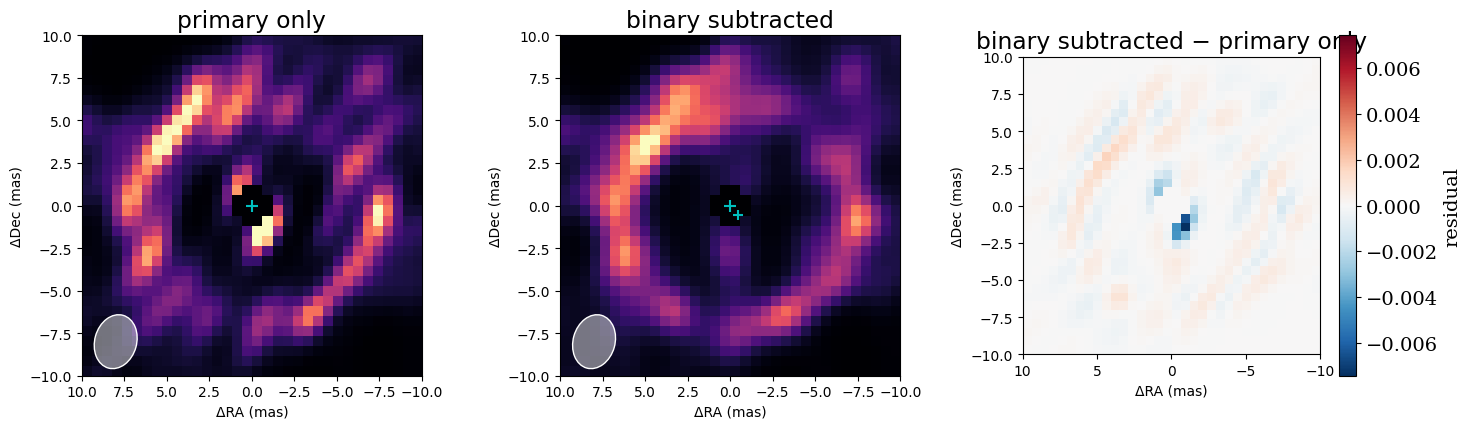

In [4]:
view, nview = 20.0, 34
rendered = {name: result.model.env.render(nview, view) for name, result in images.items()}
vmax = float(jnp.quantile(jnp.stack(list(rendered.values())), 0.995))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, (name, result) in zip(axes, images.items()):
    plot_model(result.model.env, fov_mas=view, npix=nview, ax=ax, title=name, beam=beam(data))
    ax.images[0].set_clim(0.0, vmax)
    ax.plot([0.0], [0.0], "c+", ms=9, mew=1.5)
axes[1].plot([float(secondary.dra)], [float(secondary.ddec)], "c+", ms=7, mew=1.5)
plot_residual_map(rendered["binary subtracted"] - rendered["primary only"], fov_mas=view, ax=axes[2], title="binary subtracted − primary only")
plt.tight_layout()
plt.show()

## Comparison with the paper, and summary

Set against the paper's text, this analysis finds:
- **Parametric fit:** temperatures, inclination, ring size and flux fractions within about their quoted uncertainties: 1120 ± 50 K (ring), 2400 ± 300 K (background), 19 ± 2°, a 14.15 mas diameter with a 3.2 mas FWHM, and fractions of 59.7% (primary), 20.9% (ring) and 15.5% (background).
- **Companion:** about 6% of the flux, 0.72 mas away, at about 3400 K, against their 3.9 ± 0.7%, 0.81 ± 0.05 mas and 4000 ± 2000 K. Like theirs, it is too hot and too bright for a main-sequence companion, which is their evidence for a circum-companion disc.
- **Primary-only image:** the primary has 61% of the flux, as in the paper's primary-only reconstruction. Its d_env is 0.25, against their 0.42.
- **Binary-subtracted image:** d_env is 0.45, because the companion's light is no longer counted as environment.

One number disagrees. The companion's position angle, about 219°, is roughly opposite the paper's 56 ± 3°, although the ring's brightest side (north-east) agrees with theirs. So this is not a global sign flip in the closure phases, and it needs checking against their figures or with the authors.

On the spectral parameters, d_env is only defined relative to the star's spectrum. The ratio of environment to star goes as λ^(d_env − d_star). With a 7250 K blackbody for the primary, whose slope in the H band is about −3.3 rather than −4, the same data give a d_env about 0.7 higher. Likewise, a background split off as a separate `Resolved` component, as in the previous MWE, gives the image a different index from an environment that includes it.

Two caveats remain. First, the companion's flux and separation are correlated; for so unresolved a pair, its closure phases scale roughly as flux × separation³, so a small change in separation trades against a large change in flux. Second, the anchoring assumes the paper's mass ratio. Stage 5's sampling would quantify both.